# PointNet for ModelNet40
Adapted to the ModelNet40 dataset. This notebook uses all 40 classes.

we write the dimensions as such:
- D is the amount of features (3 features: x, y, z)
- N is the amount of points per mesh
- B is the amount of batches

Among the N dimension, theres invariance by permutation because point order doesnt matter.

In [1]:
from functools import lru_cache
from pathlib import Path
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

In [2]:
PROJECT_ROOT = Path('/Users/elo/Coding/radar_ml')
DATA_ROOT = PROJECT_ROOT / 'datasets' / 'ModelNet40'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'modelNET_pointnetV1'
TRAIN_SPLIT_NAME = 'train'
TEST_SPLIT_NAME = 'test'

MODELNET_CLASS_NAMES = (
    'airplane', 'bathtub', 'bed', 'bench', 'bookshelf', 'bottle', 'bowl', 'car', 'chair', 'cone',
    'cup', 'curtain', 'desk', 'door', 'dresser', 'flower_pot', 'glass_box', 'guitar', 'keyboard', 'lamp',
    'laptop', 'mantel', 'monitor', 'night_stand', 'person', 'piano', 'plant', 'radio', 'range_hood', 'sink',
    'sofa', 'stairs', 'stool', 'table', 'tent', 'toilet', 'tv_stand', 'vase', 'wardrobe', 'xbox')
MODELNET_INDEX = {name: idx for idx, name in enumerate(MODELNET_CLASS_NAMES)}

DEVICE = "mps"
CONFIG = {
    'feature_names': ('x', 'y', 'z'),
    'feature_amount': 3,
    'points_per_model': 1024, # the amount of points from the paper that saturates performances
    'batch_size': 32,
    'dropout_rate': 0.5,
    'validation_fraction': 0.1,
    "num_epochs": 10,
    "base_lr": 1e-3,
    "lr_warmup_epochs": 5,
    "adam_momentum": 0.9,
    "lr_decay_step": 20,
    "lr_decay_gamma": 0.5,
    "accum_iter": 1,
}

# data

In [3]:
@lru_cache(maxsize=None)
def load_modelnet_file(file_path):
    "Helper to load an OFF file and return normalized vertices."
    with Path(file_path).open('r') as handle:
        header = handle.readline().split()
        counts = header[1:] if len(header) > 1 else handle.readline().split()
        vertex_count = int(counts[0])
        points = [[float(value) for value in handle.readline().split()[:3]] for _ in range(vertex_count)]

    points = torch.tensor(points, dtype=torch.float32)
    points = points - points.mean(dim=0)
    points = points / torch.norm(points, dim=1).max()
    return points

In [4]:
sample_file = next((DATA_ROOT / 'airplane' / TRAIN_SPLIT_NAME).glob('*.off'))
points = load_modelnet_file(str(sample_file))
print(len(points))
print(points.shape) # (vertices, feature_amount)

26508
torch.Size([26508, 3])


In [5]:
def build_sample_index(split_name):
    "Creates one sample per OFF file."
    samples = []

    for class_name in MODELNET_CLASS_NAMES:
        class_dir = DATA_ROOT / class_name / split_name
        for file_path in sorted(class_dir.glob('*.off')):
            samples.append((str(file_path), MODELNET_INDEX[class_name]))
    return samples

In [6]:
samples = build_sample_index(TRAIN_SPLIT_NAME)
print(len(samples))
print(samples[:1])

9843
[('/Users/elo/Coding/radar_ml/datasets/ModelNet40/airplane/train/airplane_0001.off', 0)]


In [7]:
def process_point_cloud(points):
    "Make sure every mesh has exactly points_per_model points."
    points = torch.as_tensor(points, dtype=torch.float32)

    if len(points) >= CONFIG['points_per_model']:
        idx = torch.randperm(len(points))[:CONFIG['points_per_model']]
        return points[idx]

    padded = torch.zeros((CONFIG['points_per_model'], CONFIG['feature_amount']), dtype=torch.float32)
    padded[:len(points)] = points
    return padded

In [8]:
processed_points = process_point_cloud(points)
print(processed_points.shape)

torch.Size([1024, 3])


In [ ]:
def augmentation(point_cloud):
    "Training augmentation."
    scale = torch.empty(3).uniform_(2. / 3., 3. / 2.)
    shift = torch.empty(3).uniform_(-0.2, 0.2)
    jitter = torch.randn_like(point_cloud) * 0.01
    point_cloud = point_cloud * scale + shift + jitter
    return point_cloud

In [ ]:
class ModelNetDataset(Dataset):
    "Dataset containing ModelNet point clouds."
    def __init__(self, samples, augment=False):
        self.samples = samples
        self.augment = augment

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        file_path, label_idx = self.samples[idx]
        points = load_modelnet_file(file_path)
        point_cloud = process_point_cloud(points)
        if self.augment:
            point_cloud = augmentation(point_cloud)
        label = torch.tensor(label_idx, dtype=torch.long)
        return point_cloud, label

In [11]:
data = ModelNetDataset(samples)
print(len(data))
x, y = data[0]
print(x.shape, y)

9843
torch.Size([1024, 3]) tensor(0)


# architecture

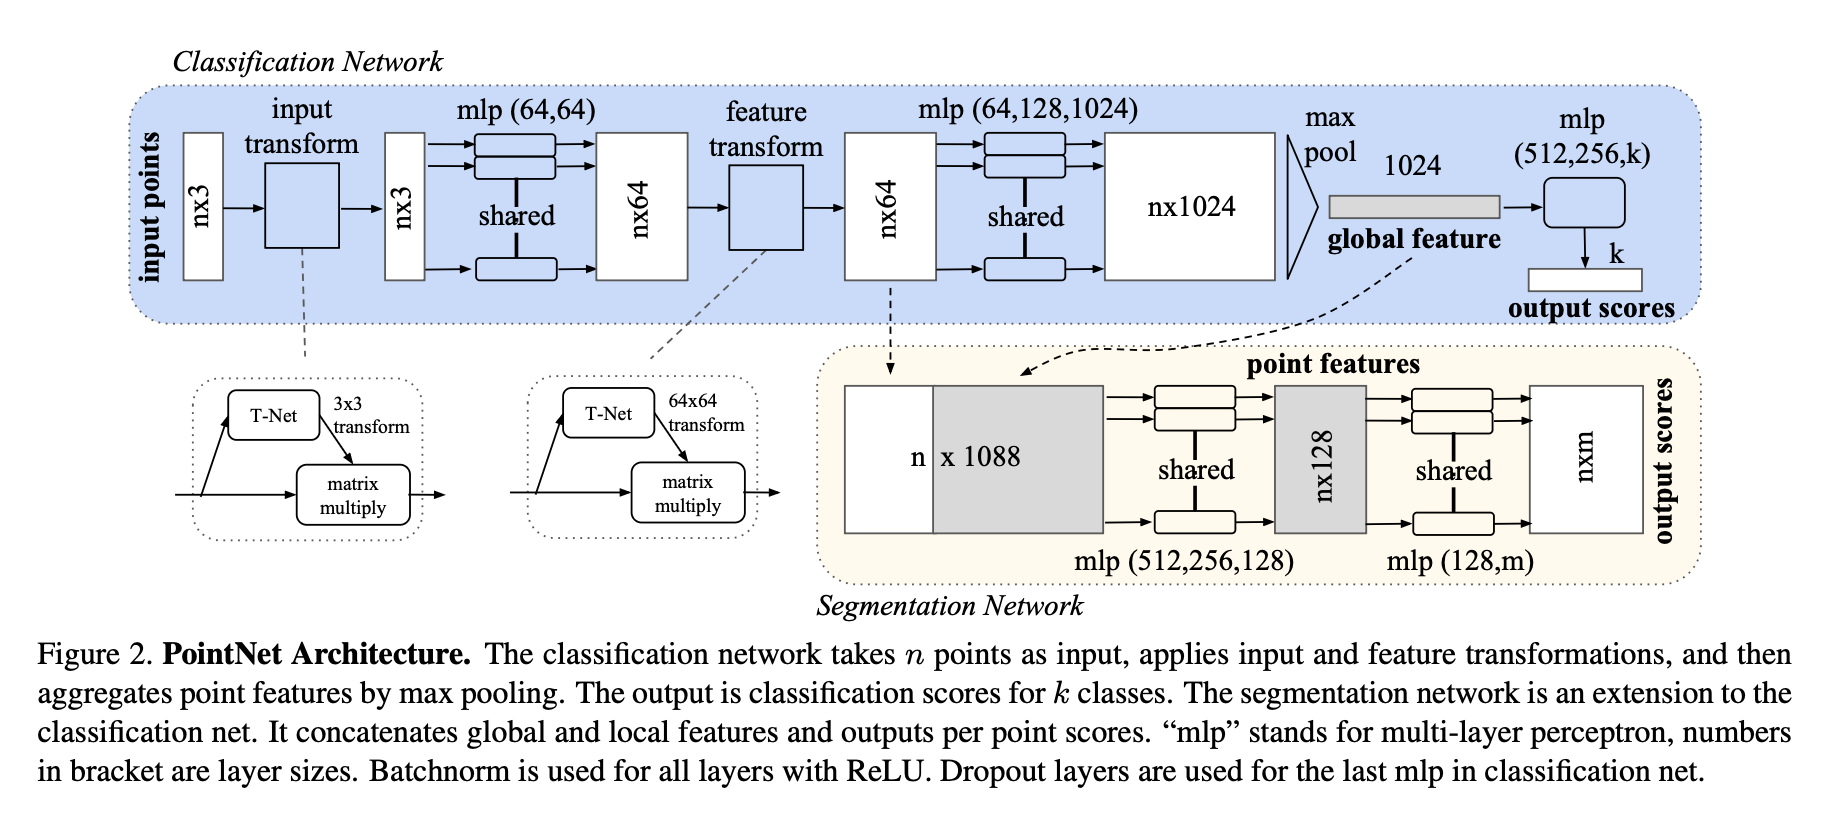

In [12]:
def xavier_init(module):
    "Helper to initialize weights with Xavier uniform, ignoring biaises and scalars."
    for p in module.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

In [ ]:
class TNet(nn.Module):
    """Layer inside the transform layers. Outputs a D*D matrix to multiply the input.``
    This is meant to rotate+scale the points to make it size/rotation invariant.
    Invertible matrix with the loss penalties.
    """
    def __init__(self, feature_count):
        super().__init__()
        self.feature_count = feature_count
        self.ff1 = nn.Linear(feature_count, 64)
        self.norm1 = PointBatchNorm(64)
        self.ff2 = nn.Linear(64, 128)
        self.norm2 = PointBatchNorm(128)
        self.ff3 = nn.Linear(128, 1024)
        self.norm3 = PointBatchNorm(1024)
        self.ff4 = nn.Linear(1024, 512)
        self.norm4 = PointBatchNorm(512)
        self.ff5 = nn.Linear(512, 256)
        self.norm5 = PointBatchNorm(256)
        self.ff6 = nn.Linear(256, feature_count * feature_count)
        xavier_init(self)
        nn.init.zeros_(self.ff6.weight)
        nn.init.zeros_(self.ff6.bias)

    def forward(self, x):
        # x : (B, N, D)
        batch_size, _, _ = x.shape
        x = F.relu(self.norm1(self.ff1(x)))
        x = F.relu(self.norm2(self.ff2(x)))
        x = F.relu(self.norm3(self.ff3(x)))
        x = torch.max(x, dim=1)[0] # max-reduction over N
        x = F.relu(self.norm4(self.ff4(x)))
        x = F.relu(self.norm5(self.ff5(x)))
        x = self.ff6(x)  # last layer isn't normalized nor activated
        mat = x.view(batch_size, self.feature_count, self.feature_count) # (B, D, D)
        eye = torch.eye(self.feature_count, device=x.device).unsqueeze(0).repeat(batch_size, 1, 1)
        # identity matrices, shape: (B, D, D)
        return mat + eye

In [14]:
class PointBatchNorm(nn.Module):
    "BatchNorm with one channel per feature; stats are over batch and points."
    def __init__(self, feature_count):
        super().__init__()
        self.norm = nn.BatchNorm1d(feature_count)

    def forward(self, x):
        if x.dim() == 2:
            return self.norm(x)

        batch_size, point_count, feature_count = x.shape
        x = x.reshape(batch_size * point_count, feature_count)
        x = self.norm(x)
        return x.view(batch_size, point_count, feature_count)

In [15]:
class EncoderBlock(nn.Module):
    """Block of the main architecture contaning a TNet tranformed
    followed by a shared mlp (a size 1 kernel convolution).
    The shared property make it oblivious to point position in the sequence"""

    def __init__(self, input_feature, mlp_dims):
        super().__init__()
        self.tnet = TNet(feature_count=input_feature)
        self.mlp_layers = nn.ModuleList()
        self.mlp_norms = nn.ModuleList()
        for in_dim, out_dim in zip(mlp_dims[:-1], mlp_dims[1:]):
            self.mlp_layers.append(nn.Linear(in_dim, out_dim))
            self.mlp_norms.append(PointBatchNorm(out_dim))
 
    def forward(self, x):
        # x: (B, N, D)
        self.trans_matrix = self.tnet(x) # (B, D, D)
        x = x @ self.trans_matrix # transform layer mutiplying the input by TNet matrix

        for linear, norm in zip(self.mlp_layers[:-1], self.mlp_norms[:-1]):
            x = F.relu(norm(linear(x)))
        return self.mlp_norms[-1](self.mlp_layers[-1](x)) # last linear not followed by ReLU


In [16]:
class Generator(nn.Module):
    "Compute logits from the global features."
    def __init__(self, class_amount, dropout_rate):
        super().__init__()
        self.ff1 = nn.Linear(1024, 512, bias=False)
        self.norm1 = PointBatchNorm(512)
        self.ff2 = nn.Linear(512, class_amount)
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        # x: (B, 1024)
        x = F.relu(self.norm1(self.ff1(x)))
        x = self.dropout(x)

        return self.ff2(x)

In [17]:
class PointNet(nn.Module):
    "The whole architecture"
    def __init__(self, feature_amount):
        super().__init__()
        self.block1 = EncoderBlock(feature_amount, [feature_amount, 64, 64])
        self.block2 = EncoderBlock(64, [64, 64, 128, 1024])
        self.generator = Generator(len(MODELNET_CLASS_NAMES), CONFIG['dropout_rate'])

    def forward(self, x):
        # x: (B, N, D)
        batch_size, _, _ = x.shape
        x = self.block1(x) # x: (B, N, 64)
        x = self.block2(x) # x: (B, N, 1024)
        x = torch.max(x, dim=1)[0]  # maxpool over N
        x = x.view(batch_size, 1024)
        logits = self.generator(x)
        return logits

In [18]:
all_train_samples = build_sample_index(TRAIN_SPLIT_NAME)
order = torch.randperm(len(all_train_samples)).tolist()
valid_count = int(len(all_train_samples) * CONFIG['validation_fraction'])
valid_indices = set(order[:valid_count])
train_samples = [sample for idx, sample in enumerate(all_train_samples) if idx not in valid_indices]
valid_samples = [sample for idx, sample in enumerate(all_train_samples) if idx in valid_indices]
test_samples = build_sample_index(TEST_SPLIT_NAME)
print(f'Train samples: {len(train_samples)}')
print(f'Validation samples: {len(valid_samples)}')
print(f'Test samples: {len(test_samples)}')

train_dataset = ModelNetDataset(train_samples, augment=True)
valid_dataset = ModelNetDataset(valid_samples)
test_dataset = ModelNetDataset(test_samples)
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=CONFIG['batch_size'], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

Train samples: 8859
Validation samples: 984
Test samples: 2468


In [19]:
model = PointNet(CONFIG["feature_amount"])
sample_batch, sample_labels = next(iter(train_loader))
print(f'Input shape: {sample_batch.shape}')
print(f'Label shape: {sample_labels.shape}')
output = model(sample_batch)
print(f'Output shape: {output.shape}')

Input shape: torch.Size([32, 1024, 3])
Label shape: torch.Size([32])
Output shape: torch.Size([32, 40])


# training

In [20]:
def create_dataloaders(batch_size):
    "Create train and validation dataloaders."
    all_train_samples = build_sample_index(TRAIN_SPLIT_NAME)
    order = torch.randperm(len(all_train_samples)).tolist()
    valid_count = int(len(all_train_samples) * CONFIG['validation_fraction'])
    valid_indices = set(order[:valid_count])
    train_samples = [sample for idx, sample in enumerate(all_train_samples) if idx not in valid_indices]
    valid_samples = [sample for idx, sample in enumerate(all_train_samples) if idx in valid_indices]
    train_dataset = ModelNetDataset(train_samples, augment=True)
    valid_dataset = ModelNetDataset(valid_samples)
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, drop_last=True)
    return train_dataloader, valid_dataloader

In [21]:
def rate(epoch, base, warmup=5):
    "Learning rate schedule."
    epoch = max(epoch, 1)
    return base * min(epoch ** (-0.5), epoch * warmup ** (-1.5))

In [ ]:
def smoothing(pred, targets, smoothing=0.2):
    "The true class becomes 1-smoothing, and the rest of the probability is distributed amongst the other classes"
    targets = targets.contiguous().view(-1)
    class_amount = pred.size(1)
    one_hot = torch.zeros_like(pred).scatter(1, targets.view(-1, 1), 1)
    one_hot = one_hot * (1 - smoothing) + (1 - one_hot) * smoothing / (class_amount - 1)
    log_prob = F.log_softmax(pred, dim=1)
    return -(one_hot * log_prob).sum(dim=1).mean()

In [23]:
def orthogonal(matrix):
    "Penalty term to make the TNet matrices more orthogonal."
    batch_size, feature_count, _ = matrix.shape # matrix: (B, D, D)
    eye = torch.eye(feature_count, device=matrix.device).unsqueeze(0).repeat(batch_size, 1, 1)
    diff = eye - matrix@matrix.transpose(-1,-2)
    return diff.pow(2).sum(dim=(-1, -2)).mean()

In [ ]:
class Loss:
    "Cross-entropy loss with smoothing. Regulation on the TNet matrices to make them orthogonal."
    def __init__(self, model, regul_coeff = 0.001):
        self.model = model
        self.regul_coeff = regul_coeff

    def __call__(self, out, targets, batch_size):
        loss_node = smoothing(out, targets)
        reg1 = orthogonal(self.model.block1.trans_matrix)
        reg2 = orthogonal(self.model.block2.trans_matrix)
        loss_node = loss_node + self.regul_coeff * (reg1 + reg2)
        loss = loss_node.detach() * batch_size
        return loss, loss_node

In [25]:
def run_epoch(data_iter, model, loss_compute, optimizer=None, mode="train", accum_iter=1):
    "Runs one epoch, either for training, either validation."
    start, device = time.time(), torch.device(DEVICE)
    total_tokens, total_loss, tokens, n_accum = 0, 0, 0, 0
    loss_list, grad_norms = [], []
    for i, (src, targets) in enumerate(data_iter):
        src, targets = src.to(device), targets.to(device)
        ntokens = targets.size(0)
        loss, loss_node = loss_compute(model.forward(src), targets, ntokens)

        if mode == "train":
            (loss_node / accum_iter).backward()
            if i % accum_iter == 0:
                if optimizer is not None:
                    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), float("inf")).item()
                    grad_norms.append(norm)
                    optimizer.step(); optimizer.zero_grad(set_to_none=True)
                n_accum += 1
        total_loss += loss; total_tokens += ntokens; tokens += ntokens
        loss_list.append((loss / ntokens).item())
        if i % 40 == 1 and mode == "train":
            lr, elapsed = optimizer.param_groups[0]["lr"], time.time() - start
            print(
                ("Batch: %6d | Accum. Step: %3d | Loss: %6.2f " + "| Samples/sec: %7.1f | Learn. Rate: %6.1e")
                % (i, n_accum, loss / ntokens, tokens / elapsed, lr)
            )
            start, tokens = time.time(), 0

    return loss_list, grad_norms

In [ ]:
def plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means):
    "Plot the losses and the gradient norm over the training process."
    x_train = [e + i / s for e, s in enumerate(train_epoch_sizes) for i in range(s)]
    x_valid = [e + i / s for e, s in enumerate(valid_epoch_sizes) for i in range(s)]
    epoch_mean_valid_losses = [m for s, m in zip(valid_epoch_sizes, epoch_means) for _ in range(s)]
    plt.figure(figsize=(10, 10))
    ax1 = plt.subplot(2, 1, 1)
    w = max(1, int((len(train_losses) / num_epochs) * 0.1))
    train_loss_rolling = pd.Series(train_losses).rolling(window=w, center=True).mean()
    plt.plot(x_train, train_losses, label="Training Loss"); plt.plot(x_train, train_loss_rolling, label="Training Loss (Avg)", color="darkblue", linewidth=1); plt.plot(x_valid, valid_losses, label="Validation Loss", alpha=0.7); plt.plot(x_valid, epoch_mean_valid_losses, label="Val Loss (Avg)", color="red", linewidth=1, linestyle="--")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend(); plt.title("Training and Validation Loss Over Epochs")
    ax1.set_xlim(0, num_epochs); ax1.set_xticks(range(num_epochs + 1))
    loss_values = pd.Series(train_losses + valid_losses + epoch_means).dropna()
    q1, q3 = loss_values.quantile(0.25), loss_values.quantile(0.75)
    bottom, top = max(0, q1 - 1.5 * (q3 - q1)), q3 + 1.5 * (q3 - q1)
    if top < loss_values.max(): ax1.set_ylim(bottom, top + max((top - bottom) * 0.05, 1e-6))
    y_min, y_max = ax1.get_ylim()
    best_mean_val = float("inf")
    for i, mean_val in enumerate(epoch_means):
        if mean_val <= best_mean_val and y_min <= mean_val <= y_max: ax1.text(i + 0.5, mean_val, f"{mean_val:.3g}", color="red", ha="center", va="bottom", fontweight="medium", clip_on=True)
        best_mean_val = min(best_mean_val, mean_val)
    ax = plt.subplot(2, 1, 2)
    plt.plot(x_train, all_grad_norms, label="Gradient Norm", color="orange"); plt.xlabel("Epochs"); plt.ylabel("Norm"); plt.legend(); plt.title("Gradient Norm over Epochs")
    ax.set_xlim(0, num_epochs); ax.set_xticks(range(num_epochs + 1))
    grad_values = pd.Series(all_grad_norms).dropna()
    q1, q3 = grad_values.quantile(0.25), grad_values.quantile(0.75)
    bottom, top = max(0, q1 - 1.5 * (q3 - q1)), q3 + 1.5 * (q3 - q1)
    if top < grad_values.max(): ax.set_ylim(bottom, top + max((top - bottom) * 0.05, 1e-6))
    ax.text(0.99, 0.02, f"Params count: {model_param_count:,}", transform=ax.transAxes, ha="right", va="bottom", fontsize=9, color="dimgray")
    plt.subplots_adjust(hspace=0.35); plt.show()

In [ ]:
def train_model(num_epochs=CONFIG["num_epochs"]):
    "Launch the training process of a model."
    print("Training process starting...", flush=True)
    model = PointNet(CONFIG["feature_amount"]).to(torch.device(DEVICE))
    model_param_count = sum(p.numel() for p in model.parameters())
    train_dataloader, valid_dataloader = create_dataloaders(batch_size=CONFIG["batch_size"])
    optimizer = torch.optim.Adam(model.parameters(), lr=rate(1, CONFIG["base_lr"], CONFIG["lr_warmup_epochs"]), betas=(CONFIG["adam_momentum"], 0.999))
    train_losses, valid_losses, all_grad_norms = [], [], []
    train_epoch_sizes, valid_epoch_sizes, epoch_means = [], [], []
    loss_compute, checkpoint_dir = Loss(model), CHECKPOINT_ROOT
    checkpoint_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(num_epochs):
        epoch_lr = rate(epoch + 1, CONFIG["base_lr"], CONFIG["lr_warmup_epochs"])
        for param_group in optimizer.param_groups: param_group["lr"] = epoch_lr
        model.train(); print(f"Epoch n°{epoch} Training ====", flush=True)
        loss_list, grad_norms = run_epoch(train_dataloader, model, loss_compute, optimizer, mode="train", accum_iter=CONFIG["accum_iter"])
        train_losses.extend(loss_list); train_epoch_sizes.append(len(loss_list)); all_grad_norms.extend(grad_norms)
        torch.save(model.state_dict(), checkpoint_dir / f"checkpoint_{epoch:02d}.pt")
        print(f"Epoch n°{epoch} Validation ====", flush=True); model.eval()
        with torch.no_grad():
            loss_list, _ = run_epoch(valid_dataloader, model, loss_compute, None, mode="eval")
        valid_losses.extend(loss_list); valid_epoch_sizes.append(len(loss_list))
        mean_val = sum(loss_list) / len(loss_list); epoch_means.append(mean_val)
        clear_output(wait=True)
        print("Training process starting...", flush=True); print(f"Epoch n°{epoch} complete | Validation loss: {mean_val:.4f}", flush=True)
        plot(train_losses, valid_losses, all_grad_norms, model_param_count, num_epochs, train_epoch_sizes, valid_epoch_sizes, epoch_means)

    return model

Training process starting...
Epoch n°29 complete | Validation loss: 1.7146


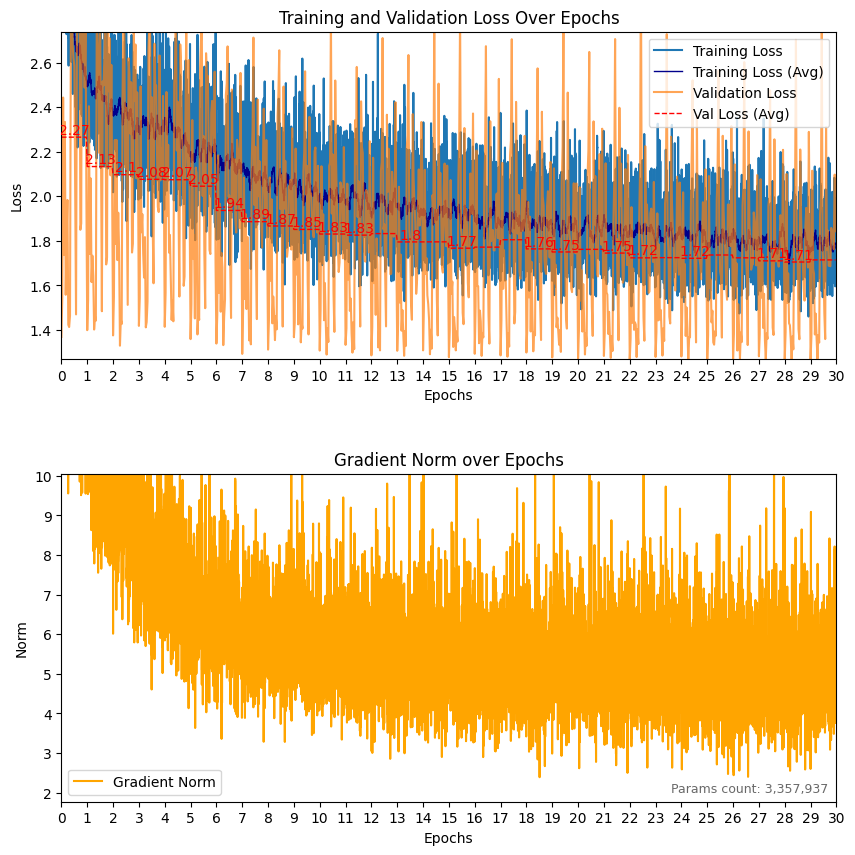

In [ ]:
if __name__ == "__main__":
    train_model(40)

# inference

In [29]:
def compute_macro_f1(predictions, labels):
    scores = []
    for class_idx in range(len(MODELNET_CLASS_NAMES)):
        true_positive = ((predictions == class_idx) & (labels == class_idx)).sum().item()
        false_positive = ((predictions == class_idx) & (labels != class_idx)).sum().item()
        false_negative = ((predictions != class_idx) & (labels == class_idx)).sum().item()
        denominator = 2 * true_positive + false_positive + false_negative
        scores.append(0.0 if denominator == 0 else 2 * true_positive / denominator)
    return torch.tensor(scores, dtype=torch.float32)

In [30]:
def evaluate_checkpoint(checkpoint_path):
    device, model = torch.device(DEVICE), PointNet(CONFIG['feature_amount']).to(DEVICE)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()

    all_train_samples = build_sample_index(TRAIN_SPLIT_NAME)
    order = torch.randperm(len(all_train_samples)).tolist()
    valid_count = int(len(all_train_samples) * CONFIG['validation_fraction'])
    valid_indices = set(order[:valid_count])
    eval_samples = [sample for idx, sample in enumerate(all_train_samples) if idx in valid_indices]
    eval_dataset = ModelNetDataset(eval_samples)
    eval_loader = DataLoader(eval_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

    all_predictions, all_labels = [], []
    with torch.no_grad():
        for batch, labels in eval_loader:
            all_predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
            all_labels.append(labels.cpu())

    predictions, labels = torch.cat(all_predictions), torch.cat(all_labels)
    per_class_f1 = compute_macro_f1(predictions, labels)
    return per_class_f1.mean().item(), {name: float(score) for name, score in zip(MODELNET_CLASS_NAMES, per_class_f1)}, (predictions == labels).float().mean().item()

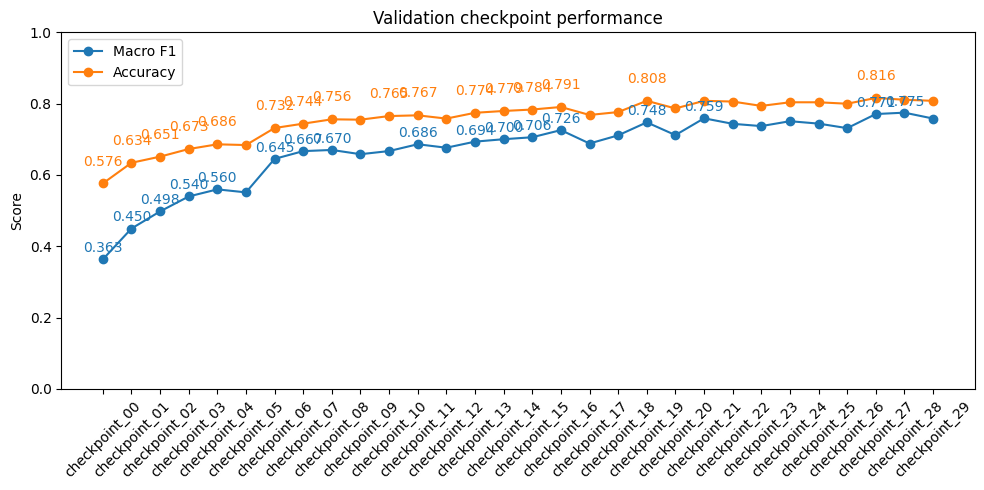

In [31]:
checkpoint_paths = sorted(CHECKPOINT_ROOT.glob("checkpoint_*.pt"), key=lambda path: int(path.stem.split("_")[-1]))
metrics = [evaluate_checkpoint(path) for path in checkpoint_paths]
checkpoint_numbers = [int(path.stem.split("_")[-1]) for path in checkpoint_paths]
checkpoint_labels = [path.stem for path in checkpoint_paths]
macro_f1_scores, accuracy_scores = ([metric[i] for metric in metrics] for i in (0, 2))

fig, ax = plt.subplots(figsize=(10, 5))
lines = [ax.plot(checkpoint_numbers, scores, marker="o", label=label)[0] for scores, label in ((macro_f1_scores, "Macro F1"), (accuracy_scores, "Accuracy"))]
for scores, line, offset in zip((macro_f1_scores, accuracy_scores), lines, (0.02, 0.05)):
    best = -1
    for checkpoint, score in zip(checkpoint_numbers, scores):
        if score > best:
            ax.text(checkpoint, score + offset, f"{score:.3f}", ha="center", color=line.get_color())
            best = score

tick_step = 1 if len(checkpoint_labels) <= 20 else max(2, (len(checkpoint_labels) + 14) // 15)
tick_indices = list(range(0, len(checkpoint_labels), tick_step))
ax.set_xticks([checkpoint_numbers[i] for i in tick_indices], [checkpoint_labels[i] for i in tick_indices], rotation=45, ha="right")
ax.set_xlim(checkpoint_numbers[0] - 0.5, checkpoint_numbers[-1] + 0.5); ax.set_ylim(min(macro_f1_scores + accuracy_scores) - 0.02, 1)
ax.set_xlabel("Checkpoint"); ax.set_ylabel("Score"); ax.set_title("Validation checkpoint performance")
ax.legend(); fig.tight_layout(); plt.show()

In [33]:
best_idx = max(range(len(accuracy_scores)), key=lambda idx: accuracy_scores[idx])
best_checkpoint_path = checkpoint_paths[best_idx]
device, model = torch.device(DEVICE), PointNet(CONFIG['feature_amount']).to(DEVICE)
model.load_state_dict(torch.load(best_checkpoint_path, map_location=device))
model.eval()

eval_samples = build_sample_index(TEST_SPLIT_NAME)
eval_dataset = ModelNetDataset(eval_samples)
eval_loader = DataLoader(eval_dataset, batch_size=CONFIG['batch_size'], shuffle=False)

all_predictions, all_labels = [], []
with torch.no_grad():
    for batch, labels in eval_loader:
        all_predictions.append(model(batch.to(device)).argmax(dim=1).cpu())
        all_labels.append(labels.cpu())

predictions, labels = torch.cat(all_predictions), torch.cat(all_labels)
per_class_f1 = compute_macro_f1(predictions, labels)
test_macro_f1, test_accuracy = per_class_f1.mean().item(), (predictions == labels).float().mean().item()
print(f'Best validation checkpoint: {best_checkpoint_path.name}')
print(f'Validation accuracy: {accuracy_scores[best_idx]:.4f}')
print(f'Test macro F1: {test_macro_f1:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')
print({name: float(score) for name, score in zip(MODELNET_CLASS_NAMES, per_class_f1)})

Best validation checkpoint: checkpoint_27.pt
Validation accuracy: 0.8161
Test macro F1: 0.7289
Test accuracy: 0.7881
{'airplane': 0.9655172228813171, 'bathtub': 0.1785714328289032, 'bed': 0.9090909361839294, 'bench': 0.6341463327407837, 'bookshelf': 0.8502415418624878, 'bottle': 0.8615384697914124, 'bowl': 0.8095238208770752, 'car': 0.9803921580314636, 'chair': 0.9514563083648682, 'cone': 0.7272727489471436, 'cup': 0.4736842215061188, 'curtain': 0.7222222089767456, 'desk': 0.5733333230018616, 'door': 0.8181818127632141, 'dresser': 0.6369426846504211, 'flower_pot': 0.06896551698446274, 'glass_box': 0.9435897469520569, 'guitar': 0.9743589758872986, 'keyboard': 0.8999999761581421, 'lamp': 0.6511628031730652, 'laptop': 0.930232584476471, 'mantel': 0.9223300814628601, 'monitor': 0.8131868243217468, 'night_stand': 0.6133333444595337, 'person': 0.604651153087616, 'piano': 0.8617021441459656, 'plant': 0.7817258834838867, 'radio': 0.4571428596973419, 'range_hood': 0.9270833134651184, 'sink': 0.